In [10]:
import importlib
import sys
import warnings
from pathlib import Path

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Ensure project root is on sys.path
_project_root = str(Path.cwd().parent)
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)

warnings.filterwarnings("ignore")

import training_configuration

importlib.reload(training_configuration)

import figure_config

importlib.reload(figure_config)

import barplots

importlib.reload(barplots)

from figure_config import (
    AXIS_SPINE_COLOR,
    AXIS_SPINE_LINEWIDTH,
    CONTEXT_COLORS,
    MODEL_COLORS,
    MODEL_LABELS,
    build_barplot_legend,
    configure_axis_spines,
)
from barplots import (
    load_figure_data,
    render_model_comparison,
    render_figure5b_augmentations,
    render_figure5b_group,
)
from training_configuration import EXTRA_MARKERS_5B_GROUPS

# Internal helper — accessed directly for composite assembly
from barplots import _prepare_figure5b_data

print("All imports OK")

All imports OK


## Panel helper functions

In [11]:
# ── Shared data loading ──────────────────────────────────────────────────

def load_all_figure_data():
    """Load all DataFrames needed by every panel."""
    df_fig4 = load_figure_data("figure4")
    df_fig6 = load_figure_data("figure6")
    dmm_df_5b, ref_df_5b = _prepare_figure5b_data()
    return df_fig4, df_fig6, dmm_df_5b, ref_df_5b


# Model lists derived from training_configuration
GROWTH_FACTOR_MODELS = [
    "EGFR_MAPK__logobs_tegfr_aggavg",
    "EGFR_MAPK__logobs_tegfr_ttgfa_tbtc_tereg_tnrg1_tnrg2_aggavg",
    "EGFR_MAPK__logobs_tegfr_tbtc_aggavg",
    "EGFR_MAPK__logobs_tegfr_tereg_aggavg",
    "EGFR_MAPK__logobs_tegfr_tnrg1_aggavg",
    "EGFR_MAPK__logobs_tegfr_tnrg2_aggavg",
    "EGFR_MAPK__logobs_tegfr_ttgfa_aggavg",
]

MUTATION_MODELS = [
    "EGFR_MAPK__logobs_tegfr_aggavg",
    "EGFR_MAPK__logobs_tegfr_mbraf_mkras_aggavg",
    "EGFR_MAPK__logobs_tegfr_mbraf_aggavg",
    "EGFR_MAPK__logobs_tegfr_mkras_aggavg",
]

# ── Data ablation scatter helper ──────────────────────────────────────────

def render_data_ablation_scatter(
    ax, df_fig6, *,
    refs=("DMM + EGFR transcript levels", "linear regression"),
    ref_colors=None,
    n_total_cell_lines=61,
    min_s=15,
    max_s=150,
    title="Data Ablation",
    xlabel="Train RMSE",
    ylabel="Test RMSE",
):
    """Train-vs-test RMSE scatter for data ablation.

    Marker size encodes number of cell lines used for training.
    Diagonal y=x line marks the over/under-fitting boundary.

    Returns:
        tuple: (color_handles, color_labels, size_handles, size_labels)
    """
    if ref_colors is None:
        ref_colors = {
            "DMM + EGFR transcript levels": MODEL_COLORS.get("DMM + EGFR tx", "#1f77b4"),
            "linear regression":            MODEL_COLORS.get("linear regression", "#000000"),
        }

    df = df_fig6.copy()
    df["ref"] = df["ref"].replace({
        "avg_model":  "negative control",
        "sample":     "positive control",
        "elasticnet": "linear regression",
        "DMM":        "DMM + EGFR transcript levels",
    })

    pct_mask = df.samples.str.contains("pct", na=False)
    train_df = df[(df.dataset == "train") & df.ref.isin(refs) & pct_mask].copy()
    val_df   = df[(df.dataset == "val")   & df.ref.isin(refs) & pct_mask].copy()

    for sub in (train_df, val_df):
        sub[["pct_missing", "seed"]] = sub["samples"].str.extract(r"_(\d+)pct_(\d+)")
        sub["pct_missing"]  = sub["pct_missing"].astype(int)
        sub["seed"]         = sub["seed"].astype(int)
        sub["n_cell_lines"] = (sub["pct_missing"] / 100 * n_total_cell_lines).round().astype(int)

    train_agg = train_df.groupby(["n_cell_lines", "seed", "ref"], as_index=False)["rmse"].mean()
    val_agg   = val_df.groupby(  ["n_cell_lines", "seed", "ref"], as_index=False)["rmse"].mean()
    merged    = train_agg.merge(val_agg, on=["n_cell_lines", "seed", "ref"],
                                suffixes=("_train", "_test"))
    mean_traj = (
        merged.groupby(["n_cell_lines", "ref"], as_index=False)[["rmse_train", "rmse_test"]]
        .mean()
        .sort_values("n_cell_lines")
    )

    size_map     = mean_traj["n_cell_lines"]
    denom        = max(size_map.max() - size_map.min(), 1)
    scaled_sizes = min_s + (size_map - size_map.min()) / denom * (max_s - min_s)

    color_handles, color_labels = [], []
    for ref in refs:
        color = ref_colors.get(ref, "#333333")
        mask  = mean_traj["ref"] == ref
        traj  = mean_traj[mask]
        sizes = scaled_sizes[mask]
        if traj.empty:
            continue
        ax.plot(traj["rmse_train"], traj["rmse_test"],
                color=color, lw=1.2, alpha=0.5, zorder=1)
        ax.scatter(traj["rmse_train"], traj["rmse_test"],
                   s=sizes, alpha=0.8, color=color,
                   edgecolors="white", linewidths=0.5, zorder=2)
        color_handles.append(
            plt.Line2D([0], [0], marker="o", color="w",
                       markerfacecolor=color, markersize=7)
        )
        color_labels.append(ref)

    # Diagonal reference (y = x)
    ax.figure.canvas.draw()
    lo = min(ax.get_xlim()[0], ax.get_ylim()[0])
    hi = max(ax.get_xlim()[1], ax.get_ylim()[1])
    ax.plot([lo, hi], [lo, hi], ls="--", color="grey", lw=0.8, zorder=0)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal", adjustable="box")

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    configure_axis_spines(ax)

    # Size legend entries
    unique_ncl   = sorted(mean_traj["n_cell_lines"].unique())
    legend_ncl   = [unique_ncl[0], unique_ncl[len(unique_ncl) // 2], unique_ncl[-1]]
    ncl_min, ncl_max = size_map.min(), size_map.max()
    size_handles = [
        ax.scatter([], [],
                   s=min_s + (n - ncl_min) / max(ncl_max - ncl_min, 1) * (max_s - min_s),
                   color="grey", edgecolors="white", linewidths=0.5)
        for n in legend_ncl
    ]
    size_labels = [f"n = {n}" for n in legend_ncl]

    return color_handles, color_labels, size_handles, size_labels

## Load all data

In [12]:
df_fig4, df_fig6, dmm_df_5b, ref_df_5b = load_all_figure_data()

## Panel A — Growth Factor Comparison

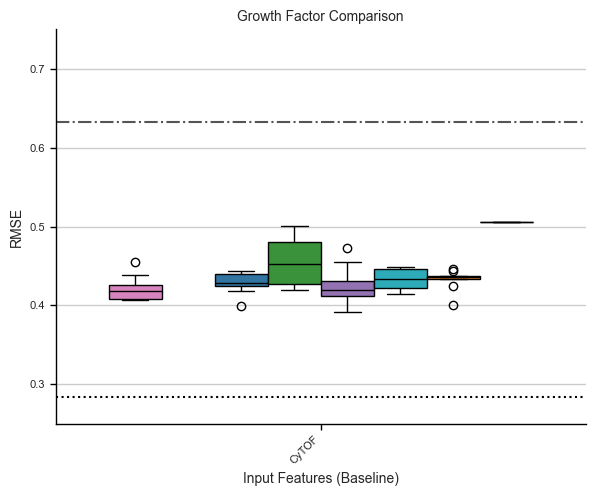

In [13]:
fig_a, ax_a = plt.subplots(figsize=(6, 5))
h_a, l_a = render_model_comparison(
    ax_a, df_fig4,
    dataset="test",
    refs=("DMM", "elasticnet"),
    ylim=(0.25, 0.75),
    models=GROWTH_FACTOR_MODELS,
    title="Growth Factor Comparison",
    group_padding=False,
)
fig_a.tight_layout()
fig_a.savefig("figX_panelA.pdf", bbox_inches="tight")
plt.show()

## Panel B — Mutation Comparison

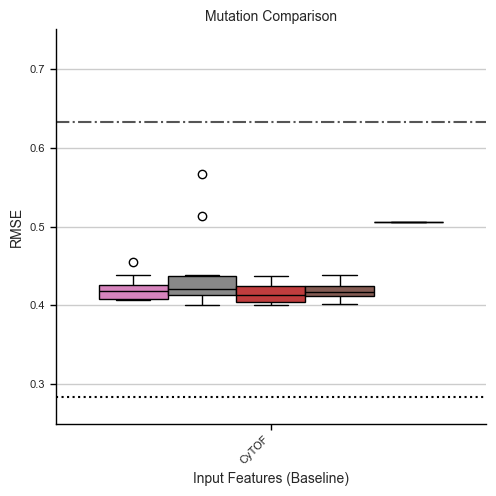

In [14]:
fig_b, ax_b = plt.subplots(figsize=(5, 5))
h_b, l_b = render_model_comparison(
    ax_b, df_fig4,
    dataset="test",
    refs=("DMM", "elasticnet"),
    ylim=(0.25, 0.75),
    models=MUTATION_MODELS,
    title="Mutation Comparison",
    group_padding=False,
)
fig_b.tight_layout()
fig_b.savefig("figX_panelB.pdf", bbox_inches="tight")
plt.show()

## Panel C — Feature Augmentations (per gene group)

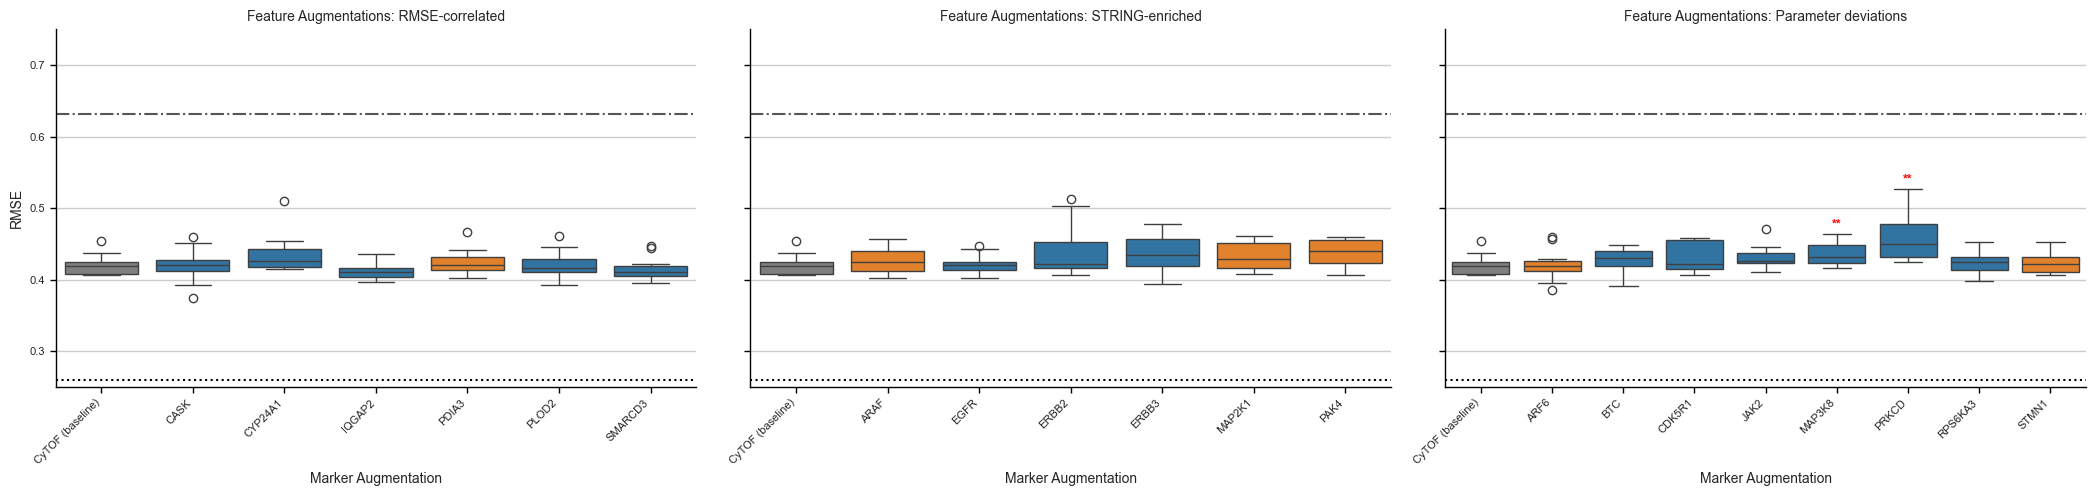

In [15]:
n_groups = len(EXTRA_MARKERS_5B_GROUPS)
fig_c, axes_c = plt.subplots(1, n_groups, figsize=(7 * n_groups, 5), sharey=True)
if n_groups == 1:
    axes_c = [axes_c]

all_h_c, all_l_c = [], []
stats_c = {}
for ax_ci, (group_name, group_markers) in zip(axes_c, EXTRA_MARKERS_5B_GROUPS.items()):
    h_ci, l_ci, stats_df_ci = render_figure5b_group(
        ax_ci, group_name, group_markers, dmm_df_5b, ref_df_5b,
        ylim=(0.25, 0.75),
        show_stats=True,
        ylabel="RMSE" if ax_ci is axes_c[0] else "",
    )
    all_h_c.extend(h_ci)
    all_l_c.extend(l_ci)
    stats_c[group_name] = stats_df_ci

fig_c.tight_layout()
fig_c.savefig("figX_panelC.pdf", bbox_inches="tight")
plt.show()

## Panel D — Data Ablation

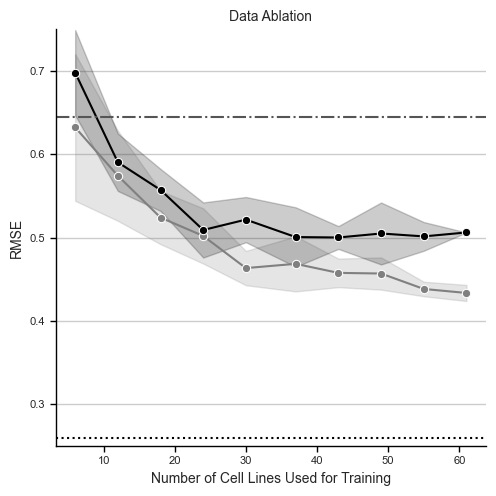

In [16]:
fig_d, ax_d = plt.subplots(figsize=(5, 5))
ch_d, cl_d, sh_d, sl_d = render_data_ablation_scatter(
    ax_d, df_fig6,
    title="Data Ablation",
)
ax_d.legend(ch_d, cl_d, loc="upper left", frameon=False, fontsize=8)
size_leg = ax_d.legend(sh_d, sl_d, title="Cell lines", loc="lower right",
                       frameon=False, fontsize=8, labelspacing=1.0)
ax_d.add_artist(size_leg)
fig_d.tight_layout()
fig_d.savefig("figX_panelD.pdf", bbox_inches="tight")
plt.show()

## Composite Figure

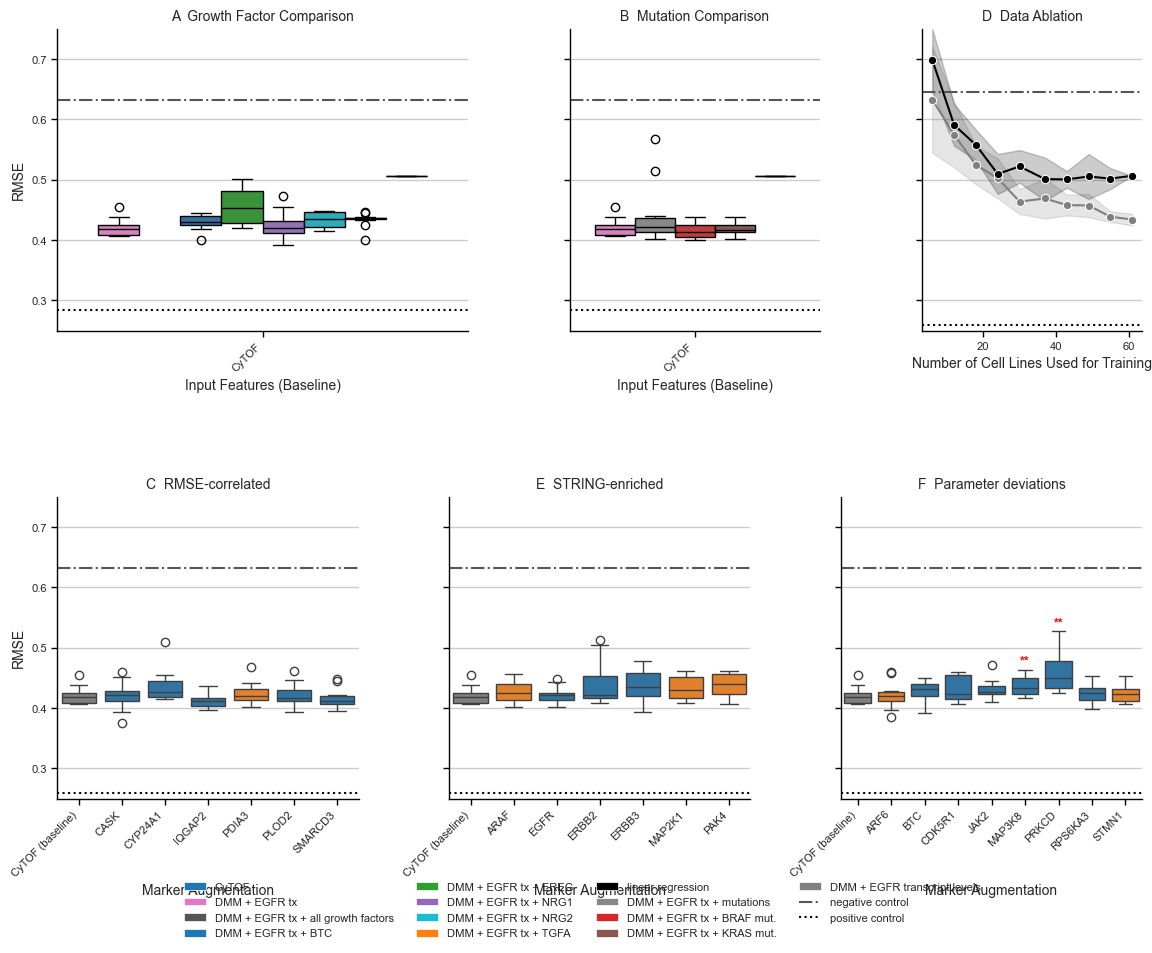

Composite figure saved.


In [17]:
# ---------------------------------------------------------------------------
# Assemble all panels into a single composite figure
# Layout (2 rows):
#   Row 1:  A (growth factors)  |  B (mutations)  |  D (data ablation)
#   Row 2:  C-group1 (augment.) |  C-group2       |  C-group3
# ---------------------------------------------------------------------------

n_groups = len(EXTRA_MARKERS_5B_GROUPS)

fig = plt.figure(figsize=(14, 10))

gs_outer = gridspec.GridSpec(
    2, 1, figure=fig,
    height_ratios=[1, 1],
    hspace=0.55,
)

# Row 1: growth factors | mutations | data ablation
gs_row1 = gridspec.GridSpecFromSubplotSpec(
    1, 3, subplot_spec=gs_outer[0],
    width_ratios=[1.4, 0.85, 0.75],
    wspace=0.35,
)

# Row 2: one column per gene group
gs_row2 = gridspec.GridSpecFromSubplotSpec(
    1, n_groups, subplot_spec=gs_outer[1],
    wspace=0.3,
)

# ── Row 1 ──────────────────────────────────────────────────────────────
ax_A = fig.add_subplot(gs_row1[0, 0])
h_A, l_A = render_model_comparison(
    ax_A, df_fig4,
    dataset="test",
    refs=("DMM", "elasticnet"),
    ylim=(0.25, 0.75),
    models=GROWTH_FACTOR_MODELS,
    title="A  Growth Factor Comparison",
    group_padding=False,
)

ax_B = fig.add_subplot(gs_row1[0, 1])
h_B, l_B = render_model_comparison(
    ax_B, df_fig4,
    dataset="test",
    refs=("DMM", "elasticnet"),
    ylim=(0.25, 0.75),
    models=MUTATION_MODELS,
    title="B  Mutation Comparison",
    ylabel="",
    group_padding=False,
)
ax_B.set_yticklabels([])

ax_D = fig.add_subplot(gs_row1[0, 2])
ch_D, cl_D, sh_D, sl_D = render_data_ablation_scatter(
    ax_D, df_fig6,
    title="D  Data Ablation",
    ylabel="Test RMSE",
)

# ── Row 2: feature augmentation groups ─────────────────────────────────
panel_letters = ["C", "E", "F", "G"]  # extend if needed

for col_i, (group_name, group_markers) in enumerate(EXTRA_MARKERS_5B_GROUPS.items()):
    ax_Ci = fig.add_subplot(gs_row2[0, col_i])
    letter = panel_letters[col_i] if col_i < len(panel_letters) else str(col_i + 3)
    render_figure5b_group(
        ax_Ci, group_name, group_markers, dmm_df_5b, ref_df_5b,
        ylim=(0.25, 0.75),
        show_stats=True,
        title=f"{letter}  {group_name}",
        ylabel="RMSE" if col_i == 0 else "",
    )
    if col_i > 0:
        ax_Ci.set_yticklabels([])

# ── Shared legend (barplot models) ─────────────────────────────────────
_all_models = list(dict.fromkeys(
    lb for lb in list(l_A) + list(l_B)
    if lb not in ("DMM", "negative control", "positive control", "")
))
_all_contexts = list(dict.fromkeys(
    t.get_text() for t in ax_A.get_xticklabels()
))
leg_h, leg_l = build_barplot_legend(_all_contexts, _all_models, include_refs=True)
fig.legend(
    leg_h, leg_l,
    loc="lower center", ncol=4, frameon=False,
    bbox_to_anchor=(0.5, -0.04), fontsize=8,
)

fig.savefig("FigureX_composite.pdf", dpi=300, bbox_inches="tight")
fig.savefig("FigureX_composite.png", dpi=300, bbox_inches="tight")
plt.show()
print("Composite figure saved.")

## Summary statistics

In [18]:
from barplots import _apply_display_labels, _split_val_test, _prepare_data

# ── Growth factor / mutation summary ─────────────────────────────────────

for label, models in [
    ("Growth Factors", GROWTH_FACTOR_MODELS),
    ("Mutations", MUTATION_MODELS),
]:
    df_disp = _apply_display_labels(df_fig4)
    data_df, _ = _split_val_test(df_disp, "test")
    data_df.features.fillna("None", inplace=True)
    plot_df, _, hue_order, contexts, _ = _prepare_data(
        data_df, None, models, ("DMM", "elasticnet"),
        ("negative control", "positive control"),
    )
    print(f"\n{'='*60}")
    print(f"  {label} — Test Set")
    print(f"{'='*60}")
    summary = (
        plot_df.groupby(["model_label", "context"])["rmse"]
        .agg(["mean", "std", "count"])
        .rename(columns={"mean": "RMSE mean", "std": "RMSE std", "count": "n"})
    )
    print(summary.to_string())

# ── Data ablation summary ─────────────────────────────────────────────────

print(f"\n{'='*60}")
print("  Data Ablation — figure6")
print(f"{'='*60}")
df6 = load_figure_data("figure6")
df6["ref"] = df6["ref"].replace({
    "avg_model": "negative control",
    "sample": "positive control",
    "elasticnet": "linear regression",
    "DMM": "DMM + EGFR transcript levels",
})
refs6 = ("DMM + EGFR transcript levels", "linear regression")
data_df6 = df6[
    (df6.dataset == "val") & df6.ref.isin(refs6) & df6.samples.str.contains("pct")
].copy()
data_df6[["pct_missing", "seed"]] = data_df6["samples"].str.extract(r"_(\d+)pct_(\d+)")
data_df6["pct_missing"] = data_df6["pct_missing"].astype(int)
data_df6["n_cell_lines"] = (data_df6["pct_missing"] / 100 * 61).round().astype(int)
abl_summary = (
    data_df6.groupby(["ref", "n_cell_lines"])["rmse"]
    .agg(["mean", "std"])
    .rename(columns={"mean": "RMSE mean", "std": "RMSE std"})
)
print(abl_summary.to_string())

# ── Feature augmentation statistics ──────────────────────────────────────

print(f"\n{'='*60}")
print("  Feature Augmentations — RMSE per marker/type")
print(f"{'='*60}")
for group_name, group_markers in EXTRA_MARKERS_5B_GROUPS.items():
    group_marker_set = set(group_markers.get("tx", ())) | set(group_markers.get("prot", ()))
    group_df = dmm_df_5b[
        (dmm_df_5b.augmentation_type == "baseline") |
        dmm_df_5b.marker.isin(group_marker_set)
    ].copy()
    baseline_rmse = group_df[group_df.augmentation_type == "baseline"]["rmse"]
    print(f"\n  Group: {group_name}")
    print(f"  Baseline RMSE: {baseline_rmse.mean():.4f} ± {baseline_rmse.std():.4f}  (n={len(baseline_rmse)})")
    for aug_type in ("transcript", "protein"):
        for marker in sorted(group_marker_set):
            sub = group_df[
                (group_df.marker == marker) & (group_df.augmentation_type == aug_type)
            ]["rmse"]
            if len(sub) > 0:
                print(f"    {aug_type:10s}  {marker:20s}  RMSE: {sub.mean():.4f} ± {sub.std():.4f}  (n={len(sub)})")


  Growth Factors — Test Set
                              RMSE mean  RMSE std   n
model_label          context                         
DMM + EGFR tx        CyTOF     0.421143  0.015530  10
DMM + EGFR tx + BTC  CyTOF     0.429249  0.013478  10
DMM + EGFR tx + EREG CyTOF     0.454859  0.030575  10
DMM + EGFR tx + NRG1 CyTOF     0.423873  0.024736  10
DMM + EGFR tx + NRG2 CyTOF     0.433300  0.013361  10
DMM + EGFR tx + TGFA CyTOF     0.432811  0.012753  10
linear regression    CyTOF     0.506256  0.000000   9

  Mutations — Test Set
                                   RMSE mean  RMSE std   n
model_label               context                         
DMM + EGFR tx             CyTOF     0.421143  0.015530  10
DMM + EGFR tx + BRAF mut. CyTOF     0.415263  0.012624  10
DMM + EGFR tx + KRAS mut. CyTOF     0.417799  0.011169  10
DMM + EGFR tx + mutations CyTOF     0.442964  0.054012  10
linear regression         CyTOF     0.506256  0.000000   9

  Data Ablation — figure6
                     